In [1]:
from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema
import numpy as np
from collections import defaultdict

def plot_surface(img, vmin=None, vmax=None):
    plt.imshow(img.T, vmin=vmin, vmax=vmax)


def compute_imgs(path_surface, params="materials/params_code.ini"):
    init_env(i_platform=0)
    xyzs, Zs, qs, _ = loadXYZ(path_surface)
    afmulator = AFMulator.from_params(params)
    afm_images = afmulator(xyzs, Zs, qs)
    
    return afmulator, afm_images


def get_minimum_surface(afmulator, afm_images, xy=(32, 14), sigma=4, generate_plots=False):
    xy = np.array(xy)
    # Actual height
    z = np.linspace(
                afmulator.scan_window[0][2],
                afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
                afmulator.scan_dim[2] - afmulator.df_steps + 1,
    )
    
    # Get all minima in the z direction and only keep the highest one
    minima = np.array(argrelextrema(afm_images, np.less_equal, axis=2)).T
    minima_dict = defaultdict(list)
    for xx, yy, zz in minima:
        minima_dict[xx, yy].append(zz)
        minima_dict[xx, yy] = [max(minima_dict[xx, yy])]
    
    argmin_image = np.zeros(afm_images.shape[0:-1], dtype=int)
    for pixel, val in minima_dict.items():
        argmin_image[pixel] = int(val[0])
    
    # Convert index to actual height
    min_image = z[argmin_image]
    blurred_image = gaussian_filter(min_image, sigma=sigma)
    
    if generate_plots:
        vmin = np.min(min_image)
        vmax = np.max(min_image)
        plt.rcParams["figure.figsize"] =  [20, 10]

        plt.subplots(1, 2)

        plt.subplot(1, 2, 1)
        plt.title("Minimas of each Pixel")
        plot_surface(min_image, vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.scatter(xy[0], xy[1], color='red')
        plt.tight_layout()
        plt.axvline(xy[0], color='orange')
        plt.axhline(xy[1], color='magenta')
        
        plt.subplot(1, 2, 2)
        plt.title(f"Blurred version {sigma=}")
        plot_surface(blurred_image, vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.scatter(xy[0], xy[1], color='red')
        plt.tight_layout()
        plt.axvline(xy[0], color='orange')
        plt.axhline(xy[1], color='magenta')
        
        plt.show()
        
        minima = argrelextrema(afm_images[xy[0], xy[1]], np.less_equal)
        
        plt.title(f"df curve for pixel {xy}")
        plt.xlabel("Distance / (Å)")
        plt.ylabel("df / (Hz)")
        plt.plot(z, afm_images[xy[0], xy[1], :])
        for minimum in minima:
            plt.scatter(z[minimum], afm_images[xy[0], xy[1], minimum], color="red")
            
        plt.show()
        
        plt.title("Slice in x direction")
        plt.plot(gaussian_filter(min_image[:,xy[1]], sigma=sigma))
        plt.plot(min_image[:,xy[1]], color="magenta")
        plt.ylabel("Height / (Å)")
        plt.show()
        
        plt.title("Slice in y direction")
        plt.plot(gaussian_filter(min_image[xy[0],:], sigma=sigma))
        plt.plot(min_image[xy[0], :], color="orange")
        plt.ylabel("Height / (Å)")
        plt.show()
    
    return min_image, blurred_image, z

 PACKAGE_PATH =  /home/henry/Documents/SharedDocuments/Uni/TU/InterdisciplinaryProject/repo/.venv_ip/lib/python3.12/site-packages/ppafm
 CPP_PATH     =  /home/henry/Documents/SharedDocuments/Uni/TU/InterdisciplinaryProject/repo/.venv_ip/lib/python3.12/site-packages/ppafm/cpp


Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


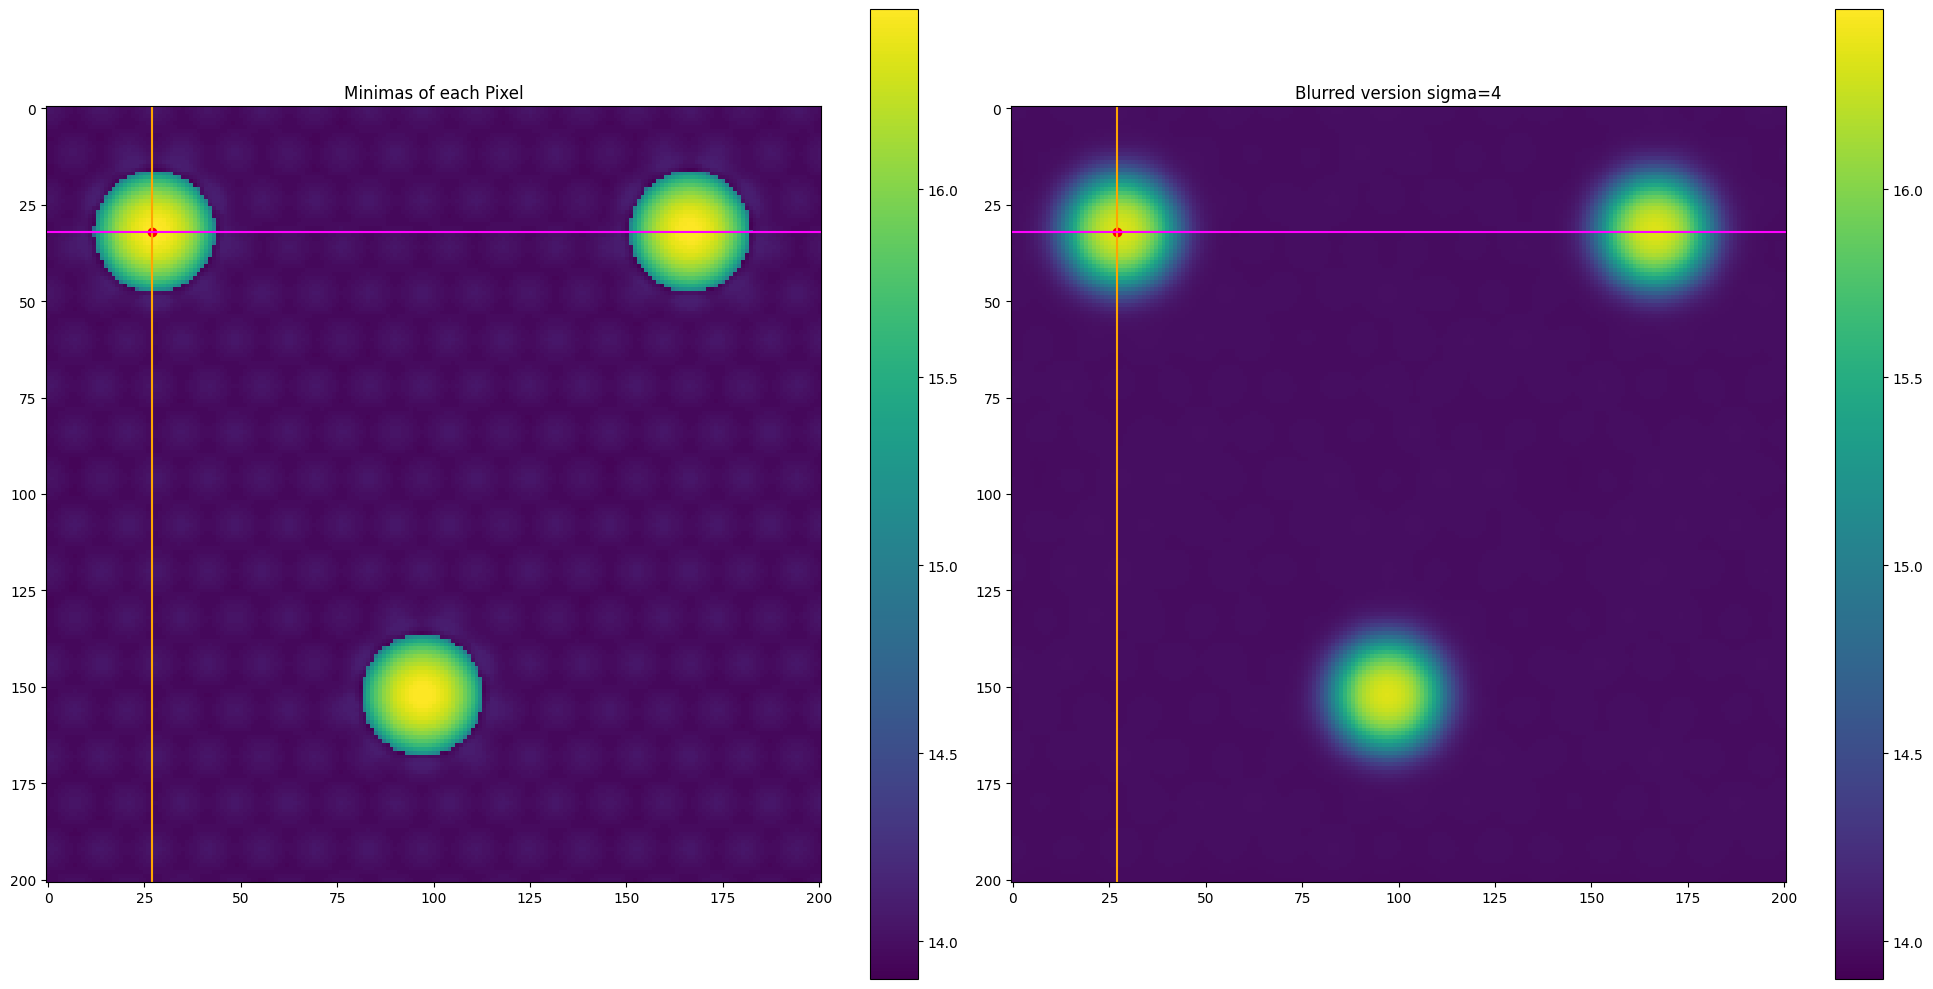

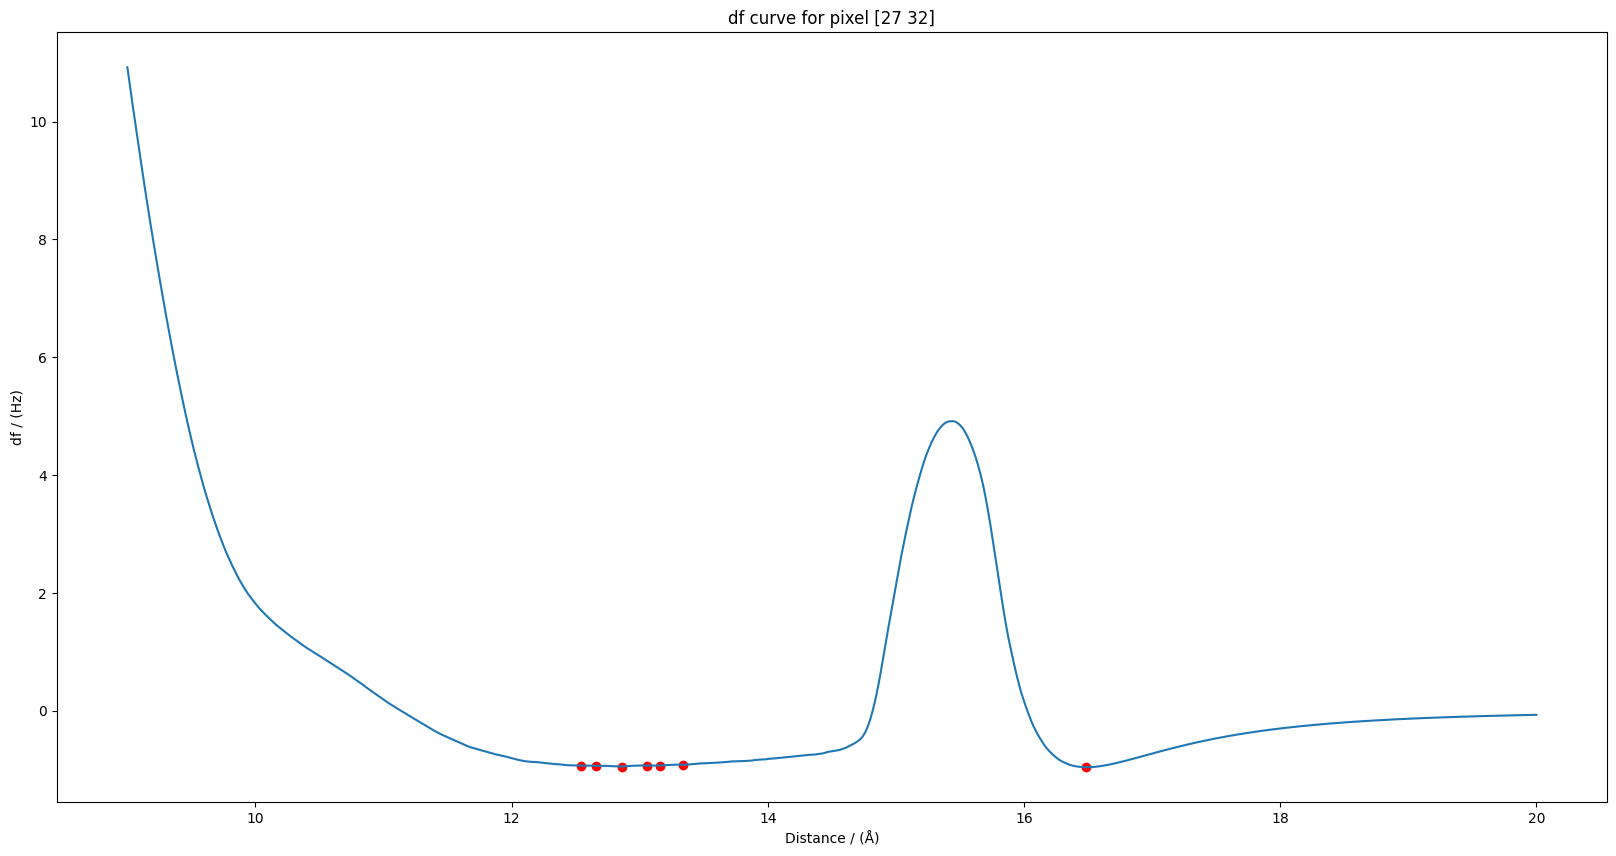

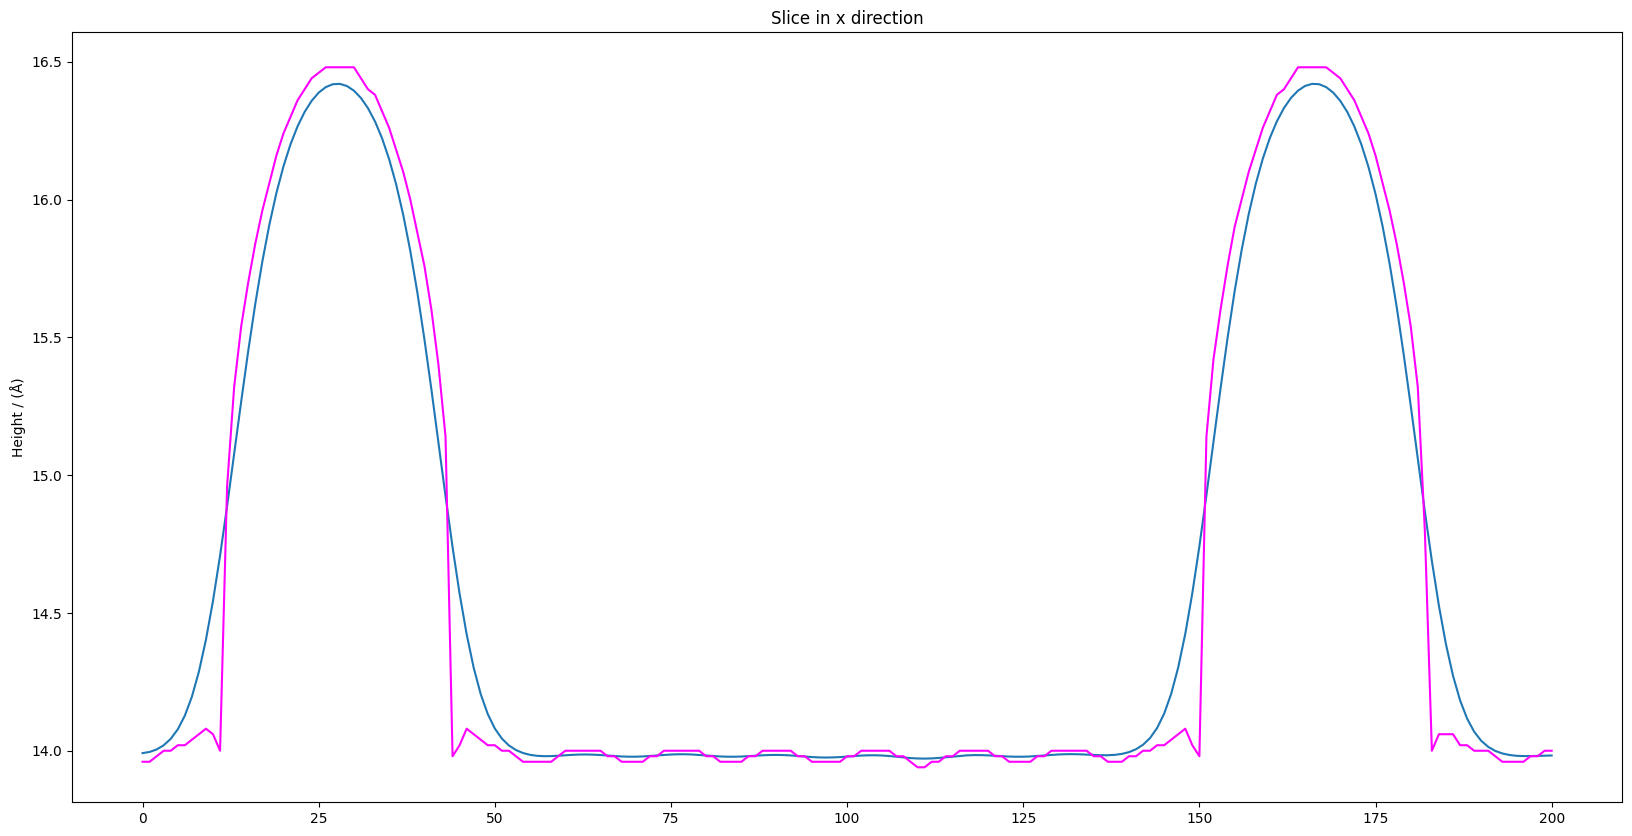

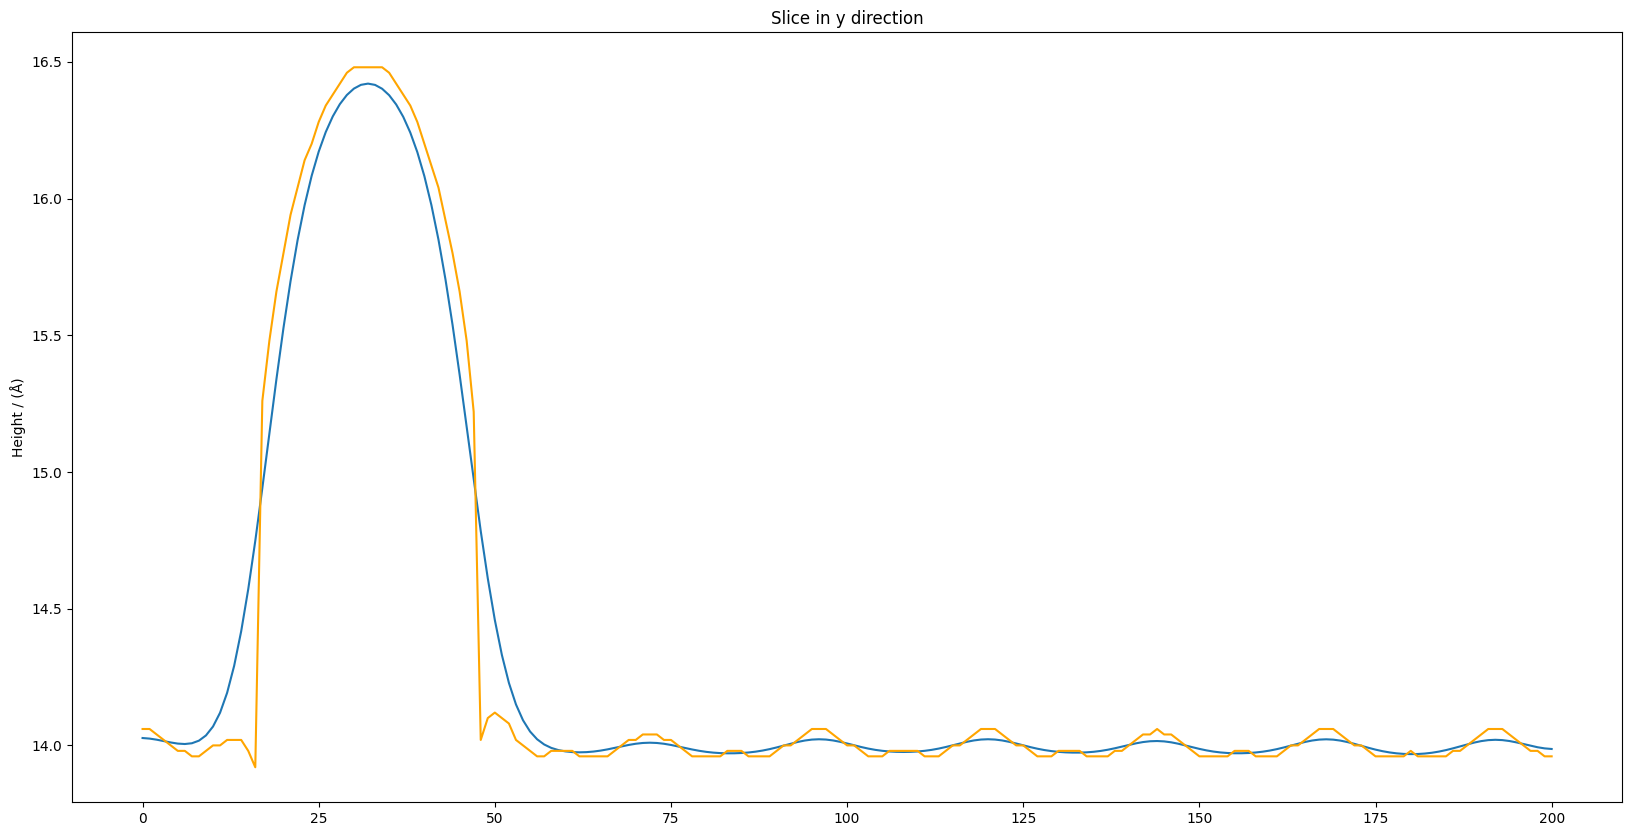

In [2]:
afmulator, afm_images = compute_imgs("materials/pt_111_small_single_adatom.xyz")
afm_images = afm_images[:,::-1,::-1]

# pt_111_smal_1_3_vacancies.xyz
xy_3_vacancy = (118, 69)
xy_1_vacancy = (21, 20)

# pt_111_small_rows_missing.xyz
xy_2row_corner = (103, 67)
xy_3row_corner = (146, 67)
xy_3row_middle = (171, 44)
xy_reference = (77, 67)

#pt_111_small_single_adatom
xy_adatom = (27, 32)

xy_test = (162, 44)
#xy_test = (200, 200)

min_image, blurred_image, z = get_minimum_surface(afmulator, afm_images, xy=xy_adatom, sigma=4, generate_plots=True)

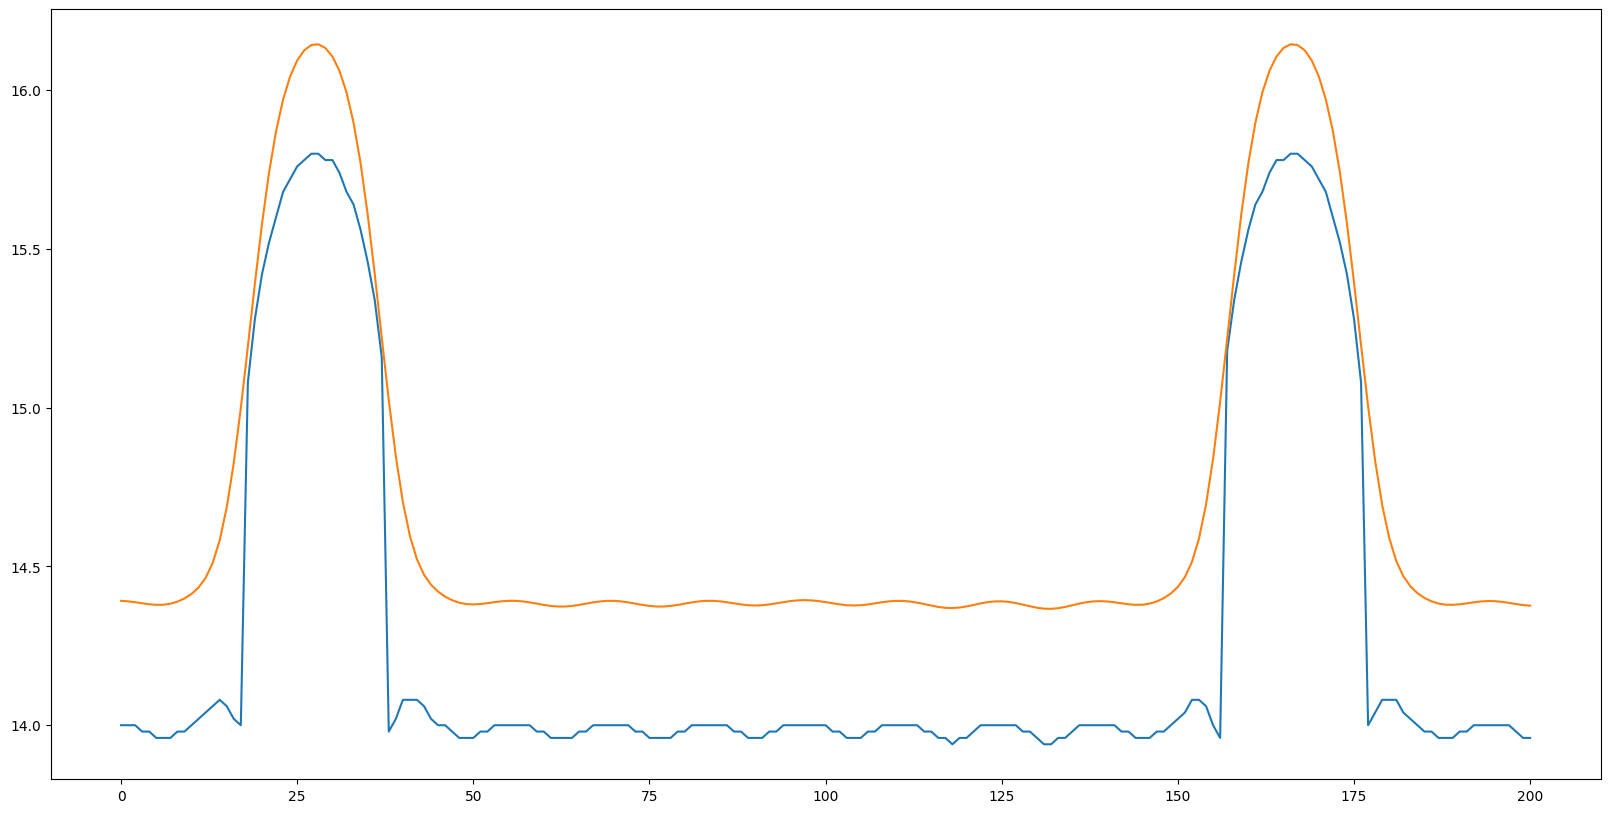

In [3]:
plt.plot(min_image[:,44])
plt.plot(gaussian_filter(min_image[:,44]+0.4, sigma=3))
#plt.plot(gaussian_filter(min_image[:,162], sigma=6))
plt.show()
#gaussian_filter(min_image[171,:], sigma=3)